# Download the screened `TS` 30MIN record for the `FF1` soil profile (2004-2025)

**notebook version**: `1` (22 Jul 2026)
**author**: Lukas Hörtnagl (holukas@ethz.ch)

## ℹ️ About this notebook

Download the **screened 30MIN** soil-temperature record of the `FF1` soil profile from the
database and write it to parquet. It applies **no corrections, no gap-filling, no homogenisation
and no flags**. It is pure I/O, and it exists so that the work which does all of that has cheap
local input instead of dozens of database queries.

**It writes two files, one per data version, and deliberately does not join them:**

| file | data version | what it holds |
|---|---|---|
| `TS_FF1_SCREENED_30MIN_DIIVE_2020-2025.parquet` | `meteoscreening_diive` | the thirteen channels of today's profile, screened by the notebooks in `20_SCREENING/TS/` |
| `TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet` | `meteoscreening_mst` | the **early** soil temperatures, under different names, screened years ago by the MeteoScreeningTool |

**Flow:** download each data version (`InfluxIO`) → its own continuous 30MIN `TIMESTAMP_MID`
index → sanity checks → parquet.

::: {.callout-important title="This is NOT a product, and its name says so"}
Every **product** in `30_PRODUCTS/` carries a number (`01` `SW_IN` … `09` `SWC`), and the number
means two things: it is a finished, corrected, documented series that downstream users may read,
and its position states what it may depend on. **This notebook has no number because it is
neither.** It is a *helper input*: the screened record exactly as it sits in the database, before
any of the steps that make a product.

The soil-temperature product will be **`10_METEO_TS_FF1_2020-2025.ipynb`**, and it does not exist
yet. It will read these files. Do not mistake them for it, and do not cite them as the CH-LAE
soil-temperature record — they are intermediates.
:::

**What is deliberately not here**, and is `10`'s job:

- **reconciling the two data versions** — which is the substantial open question, not a formality
  (see *The two data versions do not share a naming scheme*);
- the **sensor-generation flags**, any **correction, gap-filling or homogenisation**;
- the **cross-channel comparison** — depth ordering of amplitude and phase, agreement with air
  temperature — which was removed from the screening notebooks precisely so it could be done
  once, here at 30MIN, instead of thirteen times at 1MIN.

***

## 📇 Data sources

| what | where from |
|---|---|
| screened 30MIN soil temperature, 13 channels | InfluxDB `ch-lae_processed`, measurement `TS`, `data_version='meteoscreening_diive'` |
| written by | the thirteen notebooks in [`20_SCREENING/TS/`](../20_SCREENING/TS/) |

Each screening notebook downloads its own raw high-resolution channel, removes the worst outliers
(named logger artefacts and out-of-range decode garbage), resamples to 30MIN and uploads the
result back to `ch-lae_processed`. **This notebook reads that upload and nothing else.** If a
channel has not been screened and uploaded yet, it arrives here as an empty column and is
reported as such rather than passing unnoticed.

The **raw** counterpart of this file, `TS_FF1_PROFILE_RAW_2020-2025.parquet`, was written by
`x-TS_FF1_PROFILE_2020-2025.ipynb` and is **retired**. Do not use it: it is unscreened, and its
artefacts (`0.00 °C` failed reads, 40-307 °C decode garbage, the 2022 amplitude fault at
`TS_FF1_0.05_4`) are exactly what the screening removed.

## ⏱️ Timestamp convention

The database stores every timestamp in **UTC** and as **`TIMESTAMP_END`**. On download, `InfluxIO`
shifts by `TIMEZONE_OFFSET_TO_UTC_HOURS`, so the returned data are in **local time** (UTC + offset)
and still `TIMESTAMP_END`. `TimestampSanitizer(output_middle_timestamp=True)` then converts to
**`TIMESTAMP_MID`** and **raises** if the data are not 30MIN.

::: {.callout-note title="Why this file is on TIMESTAMP_MID and the screening notebooks are not"}
The thirteen `20_SCREENING/TS/` notebooks stay on `TIMESTAMP_END` from beginning to end, because
`StepwiseMeteoScreeningDb` converts to `TIMESTAMP_MID` internally and hands back `TIMESTAMP_END`
ready for upload. This notebook sits in `30_PRODUCTS/` and follows the `30_PRODUCTS/` convention
instead, so that `10` and every other product read one convention.

The practical consequence: **every timestamp quoted in a screening notebook is 15 minutes later
than the label it carries here.** The seven December 2025 artefact minutes, the April 2024 bus
failure, `TS_FF1_0.3_2`'s last record before the swap — all of those are `TIMESTAMP_END` in the
raw record and do not line up to the half-hour on this index.
:::

***

## ⚙️ Settings

In [1]:
DIRCONF = r'F:\dev\poet\configs'
# DIRCONF = r'P:\Flux\RDS_calculations\_scripts\_configs\configs'  # Folder with configuration files
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # "1" is translated to timezone "UTC+01:00" (CET, winter time)
REQUIRED_TIME_RESOLUTION = '30min'

# --- The profile ----------------------------------------------------------------------------
# All thirteen channels, written out by hand rather than built from a comprehension, because the
# profile is NOT a regular depths x replicates grid: four channels at 0.05 m, one at 0.6 m, and
# three makes of sensor. A comprehension would hide exactly what a reader needs to see.
#
#   _1     water-potential sensors of the 19 Mar 2020 install:
#          MPS-2 at 0.05 / 0.1 / 0.6 m, TEROS 21 at 0.2 / 0.3 / 0.5 m      (6 channels)
#   _2     METER TEROS 12, the same probes that report SWC_FF1_<depth>_1   (5 channels)
#   _3/_4  Campbell 109 thermistors at 0.05 m, added March 2021, analogue  (2 channels)
PROFILE = 'FF1'
CHANNELS = [
    'TS_FF1_0.05_1', 'TS_FF1_0.05_2', 'TS_FF1_0.05_3', 'TS_FF1_0.05_4',
    'TS_FF1_0.1_1', 'TS_FF1_0.1_2',
    'TS_FF1_0.2_1', 'TS_FF1_0.2_2',
    'TS_FF1_0.3_1', 'TS_FF1_0.3_2',
    'TS_FF1_0.5_1', 'TS_FF1_0.5_2',
    'TS_FF1_0.6_1',
]

BUCKET = 'ch-lae_processed'
MEASUREMENT = 'TS'
DATA_VERSION = 'meteoscreening_diive'  # what the screening notebooks upload

# --- The exported index ---------------------------------------------------------------------
# The record starts with the first measurement of the profile, not on 1 January 2020: there is no
# soil temperature before it and none is invented. Asserted against the downloaded data below.
RECORD_START = '2020-04-10'
RECORD_END = '2025-12-31'

# Two channels legitimately start 350 days after the rest - they were installed at the March 2021
# logger rebuild. Their emptiness before this date is site history, not a failed download, so it
# is asserted as EXPECTED rather than flagged as a hole.
LATE_START = {'TS_FF1_0.05_3': '2021-03-26', 'TS_FF1_0.05_4': '2021-03-26'}

# One channel is empty for 326 days in the middle: the 0.3 m TEROS 12 failed in April 2024 and its
# replacement was installed 2025-03-04, ~40 cm down the slope. Reported below, not corrected here.
SWAP_CHANNEL = 'TS_FF1_0.3_2'

# Physical plausibility of soil temperature at this site, in degC. Generous ON PURPOSE: screening
# already applied each channel's own limits, so this band only has to catch a unit or gain error
# or a wrong data_version - not weather. If it fires, something upstream is wrong.
TS_PLAUSIBLE_DEGC = (-10.0, 40.0)

# --- Output ---------------------------------------------------------------------------------
# (!) NO NUMBER. A numbered name in this folder means "product"; this is an input to one. The
# product will be 10_METEO_TS_FF1_2020-2025 and will read this file.
OUTNAME = 'TS_FF1_SCREENED_30MIN_DIIVE_2020-2025'
OUTPATH = r'F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS'

# --- The OTHER data version: the early soil temperatures -------------------------------------
# Taken from the InfluxDB Data Explorer: bucket ch-lae_processed, data_version=meteoscreening_mst,
# _measurement=TS. Twenty-one fields, and they are NOT the thirteen above.
#
# (!) THREE OF THEM REUSE TODAY'S NAMES. TS_FF1_0.05_1/_2/_3 exist in BOTH data versions and mean
#     different things in each - exactly the trap that SWC_FF1_* set (see CLAUDE.md). They must
#     never share a column with the diive era, which is why the two frames are exported to two
#     separate files and never concatenated here.
#
# The rest carry the old profile's own naming, TS_PRF_FF1_<depth>_<repl>, with depths and
# replicates today's profile does not have: 0.15 m, 1.0 m, 1.5 m, and a third replicate at most
# depths. What hardware they are, and how they map onto today's depths, is NOT decided here.
MST_DATA_VERSION = 'meteoscreening_mst'
MST_CHANNELS = [
    # today's names, but the early record - a collision, not a continuation
    'TS_FF1_0.05_1',
    'TS_FF1_0.05_2',
    'TS_FF1_0.05_3',
    # the old profile's own naming
    'TS_PRF_FF1_0.05_1',
    'TS_PRF_FF1_0.05_2',
    'TS_PRF_FF1_0.05_3',
    'TS_PRF_FF1_0.1_1',
    'TS_PRF_FF1_0.1_2',
    'TS_PRF_FF1_0.1_3',
    'TS_PRF_FF1_0.15_1',
    'TS_PRF_FF1_0.2_1',
    'TS_PRF_FF1_0.2_2',
    'TS_PRF_FF1_0.2_3',
    'TS_PRF_FF1_0.3_1',
    'TS_PRF_FF1_0.3_2',
    'TS_PRF_FF1_0.3_3',
    'TS_PRF_FF1_0.5_1',
    'TS_PRF_FF1_0.5_3',
    'TS_PRF_FF1_0.6_3',
    'TS_PRF_FF1_1.0_1',
    'TS_PRF_FF1_1.5_1',
]

# (!) TS_PRF_FF1_0.5_2 EXISTS in this data version and is deliberately NOT downloaded - it was
#     the one field left unticked in the Data Explorer selection this list came from. Recorded
#     here rather than omitted silently, because "absent from the list" and "excluded on purpose"
#     look identical six months later. Uncomment it if the exclusion was not intended.
# MST_CHANNELS.insert(17, 'TS_PRF_FF1_0.5_2')

# (!) NO hardcoded bounds for this era, on purpose. The first attempt used them and was wrong:
#     TS_PRF_FF1_0.05_2 runs to 2021-12-31, nine months past the March 2021 logger rebuild where
#     the TS_FF1_0.05_* names stop. The MeteoScreeningTool kept screening the old profile after
#     the rebuild, so "the mst era ended at the rebuild" is true of some fields and false of
#     others. The export index is therefore built from the data's own extent (padded to whole
#     days), and only a generous envelope is asserted - see "The early record on its own index".
MST_OUTNAME = 'TS_FF1_SCREENED_30MIN_MST_2004-2021'

### Imports

In [2]:
from datetime import datetime
from pathlib import Path
import importlib.metadata

import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

import diive as dv
from diive.core.io.db.influx import InfluxIO  # diive's in-house InfluxDB engine (via the diive[db] extra)
from diive.core.times.times import TimestampSanitizer

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive version: v{importlib.metadata.version('diive')}")

Last run: 2026-07-22 23:52:15
diive version: v0.91.0


### 🎨 Helpers

`plot_written_file()` draws the same three panels for both exported files, and is called on the
frame **read back from disk** rather than on the one in memory: the question these panels answer is
what a downstream notebook will actually receive.


In [3]:
def _depth_of(channel: str) -> float:
    """Depth in m from a channel name: TS_FF1_0.05_2 -> 0.05, TS_PRF_FF1_1.5_1 -> 1.5."""
    return float(channel.split('_')[-2])


def plot_written_file(df, title, flag_channels=()):
    """Three panels showing what a written file holds: the record, its gaps, its value range.

    Call it on the frame READ BACK FROM DISK, not on the in-memory one - the question is what a
    downstream notebook will receive. Nothing here computes, corrects or filters; this is the
    export, displayed. If a panel looks wrong, the file is wrong.

    Channels are ordered and coloured by DEPTH rather than by column order, because that is how the
    profile reads: the seasonal amplitude damps and its maximum lags as depth increases. Replicates
    at one depth share a colour and differ by line style, so a probe that has drifted away from its
    own neighbours shows up as a split within one colour instead of as one more line in a crowd.

    `flag_channels` marks names that need reading twice (in the early file: the three that today's
    profile also uses).
    """
    cols = sorted(df.columns, key=lambda c: (_depth_of(c), list(df.columns).index(c)))
    depths = sorted({_depth_of(c) for c in cols})
    dcolor = dict(zip(depths, plt.cm.viridis(np.linspace(0.1, 0.85, len(depths)))))
    styles = ['-', '--', ':', '-.']
    label = {c: ('(!) ' if c in flag_channels else '') + c for c in cols}

    fig, (ax_ser, ax_cov, ax_box) = plt.subplots(
        nrows=3, figsize=(15, 4.2 + 0.38 * len(cols)), dpi=100, layout='constrained',
        gridspec_kw={'height_ratios': [2.4, 1.9, 1.5]})

    # --- 1. the record itself, as daily means -------------------------------------------------
    # Daily, not 30MIN: thirteen (or twenty-one) half-hourly columns over years render as one solid
    # band. At these depths the diurnal cycle is thinner than the line anyway. A day with no record
    # stays NaN and is drawn as a break, so resampling does not paint over the gaps this file has.
    seen = set()
    for c in cols:
        d = _depth_of(c)
        rep = [x for x in cols if _depth_of(x) == d].index(c)
        daily = df[c].resample('D').mean()
        ax_ser.plot(daily.index, daily.values, lw=0.7, color=dcolor[d],
                    ls=styles[rep % len(styles)], label=f'{d} m' if d not in seen else None)
        seen.add(d)
    ax_ser.set_ylabel('soil temperature [°C]')
    ax_ser.set_title(f'{title}\ndaily means of the exported 30MIN record  '
                     f'({len(df):,} records x {len(cols)} columns, '
                     f'{df.index[0]:%Y-%m-%d} -> {df.index[-1]:%Y-%m-%d})', fontsize=11)
    ax_ser.legend(fontsize=8, ncol=min(len(depths), 9), title='depth', title_fontsize=8,
                  framealpha=0.9)
    ax_ser.grid(lw=0.4, alpha=0.4)

    # --- 2. where the records are -------------------------------------------------------------
    # The fraction of each day's 48 half hours that carries a value, so a partial outage is a shade
    # rather than absent from the picture. White is a day with nothing at all.
    cov = df[cols].notna().resample('D').mean()
    mesh = ax_cov.pcolormesh(cov.index, np.arange(len(cols)), cov[cols].T.values,
                             cmap='Blues', vmin=0, vmax=1, shading='auto')
    ax_cov.set_yticks(np.arange(len(cols)))
    ax_cov.set_yticklabels([label[c] for c in cols], fontsize=8)
    ax_cov.invert_yaxis()  # shallow at the top, as the profile stands in the ground
    ax_cov.set_xlim(ax_ser.get_xlim())
    ax_cov.set_title('Coverage per channel (white = no record that day)', fontsize=11)
    fig.colorbar(mesh, ax=ax_cov, pad=0.01, label='fraction of the day')

    # --- 3. what values are in each column ----------------------------------------------------
    # Whiskers span the full minimum to maximum, NOT a percentile - the panel is meant to show the
    # actual range on disk, so a value the export tolerated stays in the picture instead of being
    # discarded as an outlier by the plot. An all-NaN column is named rather than silently
    # missing a box, because a missing box and a box at zero look the same from a distance.
    data, pos = [], []
    for i, c in enumerate(cols):
        v = df[c].dropna().values
        if len(v):
            data.append(v)
            pos.append(i)
        else:
            ax_box.text(i, 0.5, 'empty', rotation=90, ha='center', va='center', fontsize=8,
                        color='#C62828', transform=ax_box.get_xaxis_transform())
    if data:
        bp = ax_box.boxplot(data, positions=pos, widths=0.6, whis=(0, 100), showfliers=False,
                            patch_artist=True, medianprops=dict(color='black', lw=1.0))
        for patch, c in zip(bp['boxes'], [cols[p] for p in pos]):
            patch.set_facecolor(dcolor[_depth_of(c)])
            patch.set_alpha(0.75)
        # A readable axis that is honest about what it cuts off. In the early file two values
        # (211 and -134 degC, which that era's screening tool let through) span twenty times the
        # record itself and would flatten all twenty-one boxes into a line. So the axis is set on
        # the pooled Tukey fence, and anything outside it is NAMED at the edge in red - clipped
        # for legibility, never dropped, because those values are the reason to look at all.
        allv = np.concatenate(data)
        q1, q3 = np.percentile(allv, [25, 75])
        lo = max(float(allv.min()), q1 - 1.5 * (q3 - q1))
        hi = min(float(allv.max()), q3 + 1.5 * (q3 - q1))
        pad = 0.08 * (hi - lo)
        ax_box.set_ylim(lo - pad, hi + pad)
        for i, v in zip(pos, data):
            for ex, y, va in ((float(v.min()), lo - pad, 'bottom'),
                              (float(v.max()), hi + pad, 'top')):
                if not (lo - pad <= ex <= hi + pad):
                    ax_box.annotate(f'{ex:.1f}', xy=(i, y), xytext=(0, 4 if va == 'bottom' else -4),
                                    textcoords='offset points', ha='center', va=va, rotation=90,
                                    fontsize=7.5, color='#C62828', fontweight='bold')
    ax_box.set_xticks(np.arange(len(cols)))
    ax_box.set_xticklabels([label[c] for c in cols], rotation=90, fontsize=8)
    ax_box.set_xlim(-0.7, len(cols) - 0.3)
    ax_box.set_ylabel('soil temperature [°C]')
    ax_box.set_title('Value range per column: box = IQR, whiskers = full min to max. '
                     'A red number is a value off the top or bottom of this axis', fontsize=11)
    ax_box.grid(axis='y', lw=0.4, alpha=0.5)

    plt.show()


# Negative control: a name the depth cannot be read out of must raise here, not silently sort the
# column to the front of the profile and colour it as the shallowest sensor.
try:
    _depth_of('TS_FF1_TOPSOIL_1')
except ValueError:
    print("negative control OK: _depth_of() raises on a name carrying no depth")
else:
    raise AssertionError("_depth_of() accepted a name with no depth in it")


negative control OK: _depth_of() raises on a name carrying no depth


### 🔌 Connect to database

In [4]:
dbc = InfluxIO(dirconf=DIRCONF)

> Reading configuration files was successful.

v Connection to database works.

***

## ⬇️ Download

One query for all thirteen channels over the whole period. A channel the data version does not
carry comes back as a **missing column**, not as an error — so it is added as an empty column and
named in the report below. That is the case worth watching: it means a screening notebook has not
been run and uploaded yet, and this file would silently be short a channel.

In [5]:
%%time


def download(fields, data_version, start='2020-01-01 00:00:01', stop='2026-01-01 00:00:01'):
    """Download 30MIN data and return it on a TIMESTAMP_MID index."""
    data, _, _ = dbc.download(
        bucket=BUCKET, measurements=[MEASUREMENT], fields=fields,
        start=start,  # the start date itself IS included
        stop=stop,    # the stop date itself IS NOT included
        timezone_offset_to_utc_hours=TIMEZONE_OFFSET_TO_UTC_HOURS,
        data_version=data_version)

    if data.empty:
        print(f"  ({data_version}) the query returned nothing at all.")
        return pd.DataFrame(columns=fields)

    n_dup = int(data.index.duplicated().sum())
    if n_dup:
        print(f"  ({data_version}) {n_dup} duplicated timestamp(s) - keeping the LAST")
        data = data[~data.index.duplicated(keep='last')]

    data = TimestampSanitizer(data=data, output_middle_timestamp=True,
                              nominal_freq=REQUIRED_TIME_RESOLUTION).get()

    for f in fields:
        if f not in data.columns:
            print(f"  (!) ({data_version}) no records at all for {f} - added as an empty column. "
                  f"Has its screening notebook been run and uploaded?")
            data[f] = np.nan
    return data[fields]


diive_ = download(CHANNELS, DATA_VERSION)
print(f"\ndiive frame: {diive_.shape[0]:,} rows x {diive_.shape[1]} columns")

> DOWNLOADING from bucket ch-lae_processed: variables ['TS_FF1_0.05_1', 'TS_FF1_0.05_2', 
'TS_FF1_0.05_3', 'TS_FF1_0.05_4', 'TS_FF1_0.1_1', 'TS_FF1_0.1_2', 'TS_FF1_0.2_1', 'TS_FF1_0.2_2', 
'TS_FF1_0.3_1', 'TS_FF1_0.3_2', 'TS_FF1_0.5_1', 'TS_FF1_0.5_2', 'TS_FF1_0.6_1'] from measurements 
['TS'], data version ['meteoscreening_diive'], between 2020-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 13 variables:


diive frame: 100,387 rows x 13 columns
CPU times: total: 20.1 s
Wall time: 28.5 s


### The other data version: the early soil temperatures

For soil *moisture* every `SWC_FF1_*` name also carries the **old EC-20 profile** under
`meteoscreening_mst` back to 2004 — the MeteoScreeningTool screened the earlier sensors and stored
them under the later names, so half of that column is a different instrument. The same question
had to be asked here, and the answer is: **yes, and worse.**

`meteoscreening_mst` holds **21** `TS` fields for this profile. Three of them (`TS_FF1_0.05_1`,
`_2`, `_3`) reuse names the modern profile also uses. The other eighteen carry the old profile's
own scheme, `TS_PRF_FF1_<depth>_<repl>`, and reach depths today's profile does not have — 0.15 m,
1.0 m and 1.5 m — with a third replicate at most depths.

They are downloaded here and exported **to their own file**. Nothing is merged, renamed or
reconciled: that is `10`'s job, and it needs a decision this notebook has no business making.

In [6]:
%%time
# The early record. Same helper, other data version, wider window - and its own frame, which is
# never concatenated with the diive one (three field names mean different things in the two).
mst = download(MST_CHANNELS, MST_DATA_VERSION, start='2004-01-01 00:00:01')

print(f"\nmst frame: {mst.shape[0]:,} rows x {mst.shape[1]} columns")
print(f"\n{'channel':<22s} {'records':>10s}  {'first':<19s} {'last':<19s} "
      f"{'min':>7s} {'max':>7s}")
for c in MST_CHANNELS:
    _s = mst[c].dropna()
    if len(_s):
        print(f"{c:<22s} {len(_s):10,d}  {_s.index[0]:%Y-%m-%d %H:%M}  {_s.index[-1]:%Y-%m-%d %H:%M} "
              f"{_s.min():7.2f} {_s.max():7.2f}")
    else:
        print(f"{c:<22s} {0:10,d}  (!) EMPTY - it was listed in the database but returned nothing")

> DOWNLOADING from bucket ch-lae_processed: variables ['TS_FF1_0.05_1', 'TS_FF1_0.05_2', 
'TS_FF1_0.05_3', 'TS_PRF_FF1_0.05_1', 'TS_PRF_FF1_0.05_2', 'TS_PRF_FF1_0.05_3', 'TS_PRF_FF1_0.1_1', 
'TS_PRF_FF1_0.1_2', 'TS_PRF_FF1_0.1_3', 'TS_PRF_FF1_0.15_1', 'TS_PRF_FF1_0.2_1', 'TS_PRF_FF1_0.2_2',
'TS_PRF_FF1_0.2_3', 'TS_PRF_FF1_0.3_1', 'TS_PRF_FF1_0.3_2', 'TS_PRF_FF1_0.3_3', 'TS_PRF_FF1_0.5_1', 
'TS_PRF_FF1_0.5_3', 'TS_PRF_FF1_0.6_3', 'TS_PRF_FF1_1.0_1', 'TS_PRF_FF1_1.5_1'] from measurements 
['TS'], data version ['meteoscreening_mst'], between 2004-01-01 00:00:01 and 2026-01-01 00:00:01 
(timezone offset to UTC 1)

> Downloaded data for 21 variables:


mst frame: 303,573 rows x 21 columns

channel                   records  first               last                    min     max
TS_FF1_0.05_1             263,485  2004-09-07 13:45  2021-03-24 09:45   -1.76   20.43
TS_FF1_0.05_2             177,297  2004-09-07 13:45  2021-03-24 09:45   -1.64   20.72
TS_FF1_0.05_3             266,447  2005-03-16 13:45  2021-03-24 09:45   -0.51   19.69
TS_PRF_FF1_0.05_1         269,543  2004-09-07 13:45  2021-03-24 09:45   -3.09   29.39
TS_PRF_FF1_0.05_2          29,865  2020-04-10 14:45  2021-12-31 23:45    0.90   20.00
TS_PRF_FF1_0.05_3          29,865  2020-04-10 14:45  2021-12-31 23:45    1.70   18.90
TS_PRF_FF1_0.1_1          269,575  2004-09-07 13:45  2021-03-24 09:45   -0.32   23.19
TS_PRF_FF1_0.1_2           29,865  2020-04-10 14:45  2021-12-31 23:45    1.70   18.90
TS_PRF_FF1_0.1_3           29,865  2020-04-10 14:45  2021-12-31 23:45    1.89   18.30
TS_PRF_FF1_0.15_1         269,389  2004-09-07 13:45  2021-03-24 09:45    0.14   19.95
TS_PRF_FF1

#### The two data versions do not share a naming scheme

The three colliding names are the thing to look at, and the report below measures the collision
rather than describing it. Two facts decide how `10` must treat them, and they pull in opposite
directions:

- **Before 2020-04-10** the `mst` record under `TS_FF1_0.05_*` is the *early* installation. The
  modern probes did not exist, so those values cannot be the same instrument.
- **After 2020-04-10** the two data versions **overlap**, because the MeteoScreeningTool kept
  running until the March 2021 logger rebuild. In that window they are most likely *two screenings
  of one measurement* rather than two instruments — which is the case `CLAUDE.md` says to resolve
  with `combine_first`, not with a splice.

So one column name spans, in order: an old sensor, then a new sensor screened by the old tool,
then the same new sensor screened by diive. **Do not assume the overlap means the eras are
comparable, and do not assume the pre-2020 part is the same probe.** The cell below prints what
the overlap actually contains so the question is settled on numbers, in `10`.

In [7]:
# The collision, measured. Reporting only - nothing here changes a value.
_shared = [c for c in MST_CHANNELS if c in CHANNELS]
print(f"field names present in BOTH data versions: {_shared}\n")

for c in _shared:
    # diive_ rather than ts: this cell runs BEFORE the merged frame is built.
    _m, _d = mst[c].dropna(), diive_[c].dropna()
    if not len(_m) or not len(_d):
        continue
    _ov = _m.index.intersection(_d.index)
    print(f"{c}")
    print(f"   mst   {len(_m):8,d} records  {_m.index[0]:%Y-%m-%d} -> {_m.index[-1]:%Y-%m-%d}")
    print(f"   diive {len(_d):8,d} records  {_d.index[0]:%Y-%m-%d} -> {_d.index[-1]:%Y-%m-%d}")
    if len(_ov):
        _diff = (_m.reindex(_ov) - _d.reindex(_ov)).dropna()
        print(f"   overlap {len(_ov):,} half hours, {_ov[0]:%Y-%m-%d} -> {_ov[-1]:%Y-%m-%d}")
        if len(_diff):
            _same = float((_diff.abs() < 0.001).mean() * 100)
            print(f"      mst - diive: mean {_diff.mean():+.3f} K, sd {_diff.std():.3f} K, "
                  f"max |diff| {_diff.abs().max():.3f} K")
            print(f"      identical to 0.001 K in {_same:.1f} % of the overlap")
            print(f"      -> {'looks like ONE measurement screened twice' if _same > 50 else 'the two screenings DISAGREE - 10 must find out why'}")
    else:
        print("   no overlap at all - the eras are disjoint, as they are for SWC")
    print()

field names present in BOTH data versions: ['TS_FF1_0.05_1', 'TS_FF1_0.05_2', 'TS_FF1_0.05_3']

TS_FF1_0.05_1
   mst    263,485 records  2004-09-07 -> 2021-03-24
   diive   98,604 records  2020-04-10 -> 2025-12-31
   overlap 16,695 half hours, 2020-04-10 -> 2021-03-24
      mst - diive: mean -0.428 K, sd 0.310 K, max |diff| 1.936 K
      identical to 0.001 K in 0.0 % of the overlap
      -> the two screenings DISAGREE - 10 must find out why

TS_FF1_0.05_2
   mst    177,297 records  2004-09-07 -> 2021-03-24
   diive   98,495 records  2020-04-10 -> 2025-12-31
   overlap 16,695 half hours, 2020-04-10 -> 2021-03-24
      mst - diive: mean -0.166 K, sd 1.135 K, max |diff| 3.866 K
      identical to 0.001 K in 0.0 % of the overlap
      -> the two screenings DISAGREE - 10 must find out why

TS_FF1_0.05_3
   mst    266,447 records  2005-03-16 -> 2021-03-24
   diive   82,652 records  2021-03-26 -> 2025-12-31
   no overlap at all - the eras are disjoint, as they are for SWC



### The early record on its own index

Its own continuous 30MIN index, **built from the data's own extent** rather than from constants:
this record's identity is still open, so its bounds are not something to assert in advance. The
first version of this cell did hardcode them, and was wrong within a day — `TS_PRF_FF1_0.05_2`
carries records to 2021-12-31, nine months past the March 2021 logger rebuild at which the three
`TS_FF1_0.05_*` names stop. **The MeteoScreeningTool went on screening the old profile after the
rebuild**, so there is no single date at which "the mst era" ends, and any bound written here by
hand would be a guess about a record nobody has characterised yet.

What is still asserted is a generous envelope (a wrong bucket or data version, not a surprise
year), that every record lands on the 30MIN middle-timestamp grid, and that the year label in
`MST_OUTNAME` still matches what arrived.

In [8]:
_first = min(mst[c].dropna().index[0] for c in MST_CHANNELS if mst[c].notna().any())
_last = max(mst[c].dropna().index[-1] for c in MST_CHANNELS if mst[c].notna().any())
print(f"the early record actually spans: {_first} -> {_last}")

# Generous envelope: this only has to catch a wrong bucket or data version, not a surprise year.
assert pd.Timestamp('2003-01-01') < _first < pd.Timestamp('2010-01-01'), \
    f"unexpected first record {_first} for the mst era"
assert pd.Timestamp('2019-01-01') < _last < pd.Timestamp('2025-01-01'), \
    f"unexpected last record {_last} for the mst era"

# Which fields outlive the March 2021 logger rebuild? Not a fault - a fact about this era that
# the first version of this notebook got wrong, so it is printed rather than assumed either way.
_REBUILD = pd.Timestamp('2021-03-26')
_late = {c: mst[c].dropna().index[-1] for c in MST_CHANNELS
         if mst[c].notna().any() and mst[c].dropna().index[-1] > _REBUILD}
print(f"\nfields still screened by the MeteoScreeningTool after the {_REBUILD:%Y-%m-%d} rebuild: "
      f"{len(_late)} of {len(MST_CHANNELS)}")
for c, _t in sorted(_late.items(), key=lambda kv: kv[1]):
    print(f"   {c:<22s} last record {_t:%Y-%m-%d %H:%M}")

# The index is the data's own span, padded to whole days. Anchored ON the data, so the 15/45
# middle-timestamp phase is inherited rather than reinvented - a date_range floored to the hour
# would land on :00/:30 and reindex every column to all-NaN.
_start = _first.normalize() + pd.Timedelta('15min')
_end = _last.normalize() + pd.Timedelta('23h45min')
mst_index = pd.date_range(_start, _end, freq='30min', name='TIMESTAMP_MIDDLE')

mst_export = pd.DataFrame(index=mst_index)
for c in MST_CHANNELS:
    _s = mst[c].dropna()
    if len(_s):
        # Cannot fire on a bounds problem any more - the index spans the data by construction.
        # It CAN still fire if a record sits off the 30MIN middle-timestamp grid, which would
        # mean the source is not what this notebook thinks it is.
        _outside = _s.index.difference(mst_index)
        assert _outside.empty, (
            f"{c}: {len(_outside):,} record(s) off the 30MIN middle-timestamp grid "
            f"({_outside[0]} ... {_outside[-1]}) - not a bounds problem, check the source")
    mst_export[c] = _s.reindex(mst_index)

assert mst_export.index.is_monotonic_increasing and not mst_export.index.has_duplicates
_lo, _hi = TS_PLAUSIBLE_DEGC
for c in MST_CHANNELS:
    _s = mst_export[c].dropna()
    if len(_s):
        _bad = _s[(_s < _lo) | (_s > _hi)]
        if not _bad.empty:
            print(f"(!) {c}: {len(_bad)} value(s) outside {TS_PLAUSIBLE_DEGC} degC, "
                  f"e.g. {_bad.iloc[0]:.2f} at {_bad.index[0]} - this era was screened by a "
                  f"different tool and is NOT re-screened here")

# The filename label has to keep matching the data, now that no constant pins it.
for _lbl, _val in [('start', _first), ('end', _last)]:
    _in_name = MST_OUTNAME.split('_')[-1].split('-')[0 if _lbl == 'start' else 1]
    if str(_val.year) != _in_name:
        print(f"\n(!) MST_OUTNAME says {_lbl} {_in_name} but the data {_lbl}s in {_val.year} "
              f"- rename the output before anyone relies on the label")

print(f"\nmst frame for export: {len(mst_export):,} records x {len(mst_export.columns)} columns, "
      f"{mst_export.index[0]} -> {mst_export.index[-1]}")
display(mst_export.notna().sum().rename('records').to_frame())

the early record actually spans: 2004-09-07 13:45:00 -> 2021-12-31 23:45:00

fields still screened by the MeteoScreeningTool after the 2021-03-26 rebuild: 10 of 21
   TS_PRF_FF1_0.05_2      last record 2021-12-31 23:45
   TS_PRF_FF1_0.05_3      last record 2021-12-31 23:45
   TS_PRF_FF1_0.1_2       last record 2021-12-31 23:45
   TS_PRF_FF1_0.1_3       last record 2021-12-31 23:45
   TS_PRF_FF1_0.2_2       last record 2021-12-31 23:45
   TS_PRF_FF1_0.2_3       last record 2021-12-31 23:45
   TS_PRF_FF1_0.3_2       last record 2021-12-31 23:45
   TS_PRF_FF1_0.3_3       last record 2021-12-31 23:45
   TS_PRF_FF1_0.5_3       last record 2021-12-31 23:45
   TS_PRF_FF1_0.6_3       last record 2021-12-31 23:45
(!) TS_PRF_FF1_0.2_1: 2 value(s) outside (-10.0, 40.0) degC, e.g. 211.28 at 2018-09-19 09:15:00 - this era was screened by a different tool and is NOT re-screened here
(!) TS_PRF_FF1_1.5_1: 2 value(s) outside (-10.0, 40.0) degC, e.g. -134.32 at 2018-09-19 09:15:00 - this era was screen

,records
TS_FF1_0.05_1,263485
TS_FF1_0.05_2,177297
TS_FF1_0.05_3,266447
TS_PRF_FF1_0.05_1,269543
TS_PRF_FF1_0.05_2,29865
TS_PRF_FF1_0.05_3,29865
TS_PRF_FF1_0.1_1,269575
TS_PRF_FF1_0.1_2,29865
TS_PRF_FF1_0.1_3,29865
TS_PRF_FF1_0.15_1,269389


In [9]:
_mst_path = dv.save_parquet(filename=MST_OUTNAME, data=mst_export, outpath=OUTPATH)
print(f"Saved to: {_mst_path}")

_mst_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{MST_OUTNAME}.parquet"))
assert list(_mst_written.columns) == list(MST_CHANNELS), "unexpected columns in the written file"
assert len(_mst_written) == len(mst_export), "record count changed on write"
assert _mst_written.index.equals(mst_export.index), "index changed on write"
for _c in MST_CHANNELS:
    assert int(_mst_written[_c].notna().sum()) == int(mst_export[_c].notna().sum()), \
        f"{_c}: non-null count changed on write - gaps may have become zeros"
print("Written mst parquet verified.")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet (0.210 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet


> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_MST_2004-2021.parquet (0.044 seconds).

Written mst parquet verified.


#### What the early file holds

The file just read back, drawn as it stands. This is the era nobody has characterised yet, so the
panels are there to put its shape on the table for `10` rather than to decorate the export.

Two things to read out of them:

- **Coverage splits the twenty-one columns into four groups that share nothing but a name prefix.**
  A 2004-2021 core; a pair (`TS_PRF_FF1_0.3_1`, `_0.5_1`) that ends on 2010-03-06 and never
  resumes — the date the legacy fieldbook gives for the fuse that slipped out of the forest-floor
  logger; three columns that exist only for 2017-2018; and ten that begin on 2020-04-10, which is
  the *modern* profile's first day, so those ten are today's probes screened by the old tool. One
  file, four records.
- **The value range is where this file differs from the other one in kind.** `TS_PLAUSIBLE_DEGC` is
  *asserted* on the diive frame and would abort the notebook; here the same band is only reported,
  because this era was screened by a different tool and is deliberately not re-screened. That is
  why the whiskers span the full minimum to maximum: `TS_PRF_FF1_0.2_1` reaching 211 °C and
  `TS_PRF_FF1_1.5_1` reaching -134 °C are *in the exported file*, and a downstream reader has to
  see them rather than have them trimmed away as outliers by the plot.


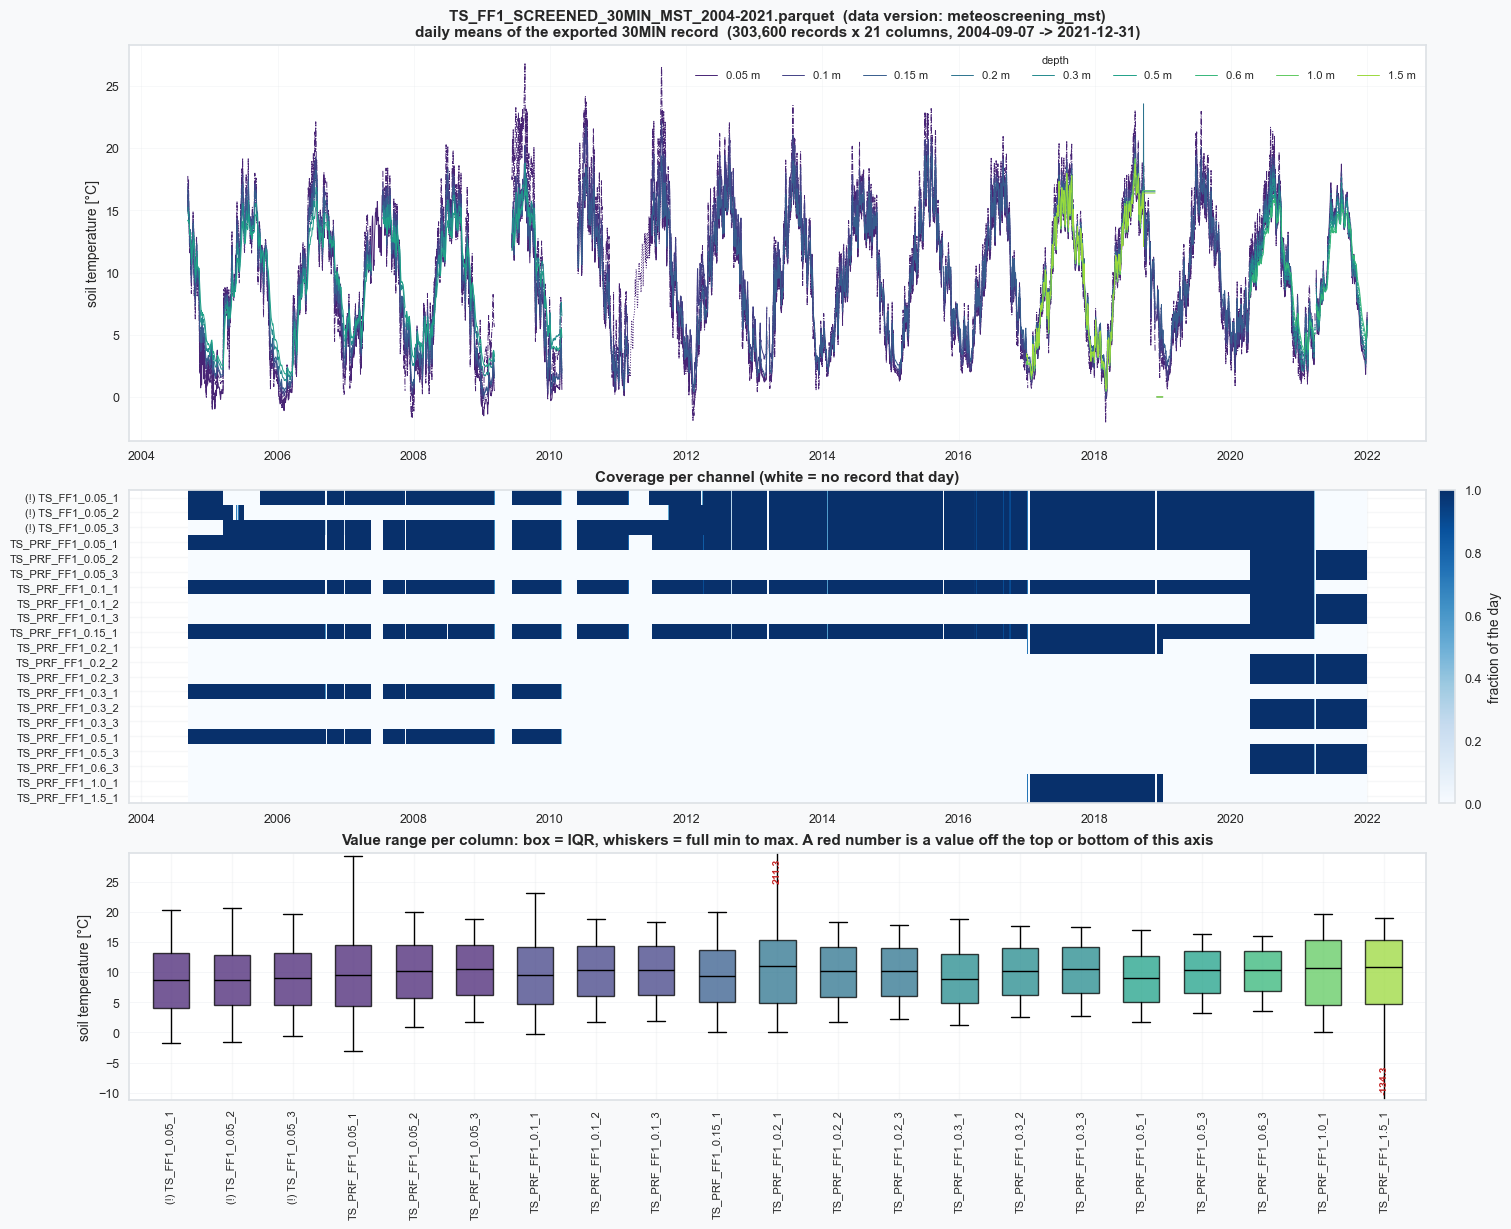

In [10]:
plot_written_file(_mst_written,
                  title=f'{MST_OUTNAME}.parquet  (data version: {MST_DATA_VERSION})',
                  flag_channels=set(MST_CHANNELS) & set(CHANNELS))


***

## 🧱 One continuous 30MIN index

The exported frame runs from the first measurement of the profile to the end of the record, with
**no missing timestamps** — a gap in a channel is a `NaN`, never an absent row. Nothing may fall
off the edge of that index, which is asserted rather than left to `reindex()` to drop in silence.

In [11]:
full_index = pd.date_range(f'{RECORD_START} 00:15:00', f'{RECORD_END} 23:45:00',
                           freq='30min', name='TIMESTAMP_MIDDLE')
ts = pd.DataFrame(index=full_index)

for c in CHANNELS:
    _s = diive_[c].dropna()
    if len(_s):
        _outside = _s.index.difference(full_index)
        assert _outside.empty, (
            f"{c}: {len(_outside):,} records lie outside the exported index "
            f"({_outside[0]} ... {_outside[-1]}) - widen RECORD_START/RECORD_END")
    ts[c] = _s.reindex(full_index)

print(f"merged frame: {len(ts):,} records, {ts.index[0]} -> {ts.index[-1]}")
ts

merged frame: 100,416 records, 2020-04-10 00:15:00 -> 2025-12-31 23:45:00


,TS_FF1_0.05_1,TS_FF1_0.05_2,TS_FF1_0.05_3,TS_FF1_0.05_4,TS_FF1_0.1_1,TS_FF1_0.1_2,TS_FF1_0.2_1,TS_FF1_0.2_2,TS_FF1_0.3_1,TS_FF1_0.3_2,TS_FF1_0.5_1,TS_FF1_0.5_2,TS_FF1_0.6_1
TIMESTAMP_MIDDLE,,,,,,,,,,,,,
2020-04-10 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-10 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-10 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-10 01:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-04-10 02:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,3.200000,2.200000,1.209706,-2.535063,3.493333,3.396667,3.500000,2.973333,4.270000,3.3,5.0,5.1,5.953333
2025-12-31 22:15:00,3.193333,2.200000,1.192398,-2.631428,3.435000,3.393333,3.500000,2.901667,4.221667,3.3,5.0,5.1,5.913333
2025-12-31 22:45:00,3.131667,2.200000,1.175669,-2.665939,3.400000,3.363333,3.500000,2.900000,4.200000,3.3,5.0,5.1,5.901667


***

## ✅ Sanity checks

Cheap, and they assert rather than assume. Note what is **not** asserted: completeness. This
profile is legitimately incomplete — two channels start a year late, one is empty for 326 days,
and the whole station has five shared outages — so a blanket "no empty columns" check would be
refusing over facts of site history. What *is* asserted is that the index is sound, that the
values are physically possible, and that the known-empty stretches are empty for the reason
expected.

In [12]:
# --- the index itself ---
assert ts.index.is_monotonic_increasing, "index is not sorted"
assert not ts.index.has_duplicates, "duplicated timestamps in the exported index"
assert pd.infer_freq(ts.index) == '30min', f"index is not 30MIN: {pd.infer_freq(ts.index)}"
assert ts.index.name == 'TIMESTAMP_MIDDLE', "index name is not TIMESTAMP_MIDDLE"
print(f"index OK: {len(ts):,} records, continuous 30MIN, {ts.index[0]} -> {ts.index[-1]}")

# --- at least something arrived ---
_empty = [c for c in CHANNELS if not ts[c].notna().any()]
assert len(_empty) < len(CHANNELS), "(!) every channel is empty - wrong bucket or data_version?"
if _empty:
    print(f"\n(!) {len(_empty)} channel(s) carry NO data and were exported empty: {_empty}")
    print("    Run their screening notebooks and re-run this one before using the file.")

# --- physical plausibility: only catches a unit/gain error, not weather ---
_lo, _hi = TS_PLAUSIBLE_DEGC
for c in CHANNELS:
    _s = ts[c].dropna()
    if not len(_s):
        continue
    _bad = _s[(_s < _lo) | (_s > _hi)]
    assert _bad.empty, (f"{c}: {len(_bad)} value(s) outside {TS_PLAUSIBLE_DEGC} degC, "
                        f"e.g. {_bad.iloc[0]:.2f} at {_bad.index[0]} - wrong data_version, "
                        f"or screening did not remove what it should have")
print(f"all values within {TS_PLAUSIBLE_DEGC} degC")

# --- the record starts where the profile was first logged ---
_first = min(ts[c].dropna().index[0] for c in CHANNELS if ts[c].notna().any())
assert _first < pd.Timestamp(RECORD_START) + pd.Timedelta('2D'), (
    f"first record is {_first}, later than RECORD_START={RECORD_START} - check the download")
print(f"first record in the profile: {_first}")

# --- the late starters are empty BEFORE their install date, and that is expected ---
for c, _start in LATE_START.items():
    if not ts[c].notna().any():
        continue
    _before = ts.loc[ts.index < pd.Timestamp(_start), c].notna().sum()
    assert _before == 0, (f"{c}: {_before} records before {_start}, but this sensor was only "
                          f"installed at the March 2021 logger rebuild")
    print(f"{c}: correctly empty before {_start} (installed at the logger rebuild)")

index OK: 100,416 records, continuous 30MIN, 2020-04-10 00:15:00 -> 2025-12-31 23:45:00
all values within (-10.0, 40.0) degC
first record in the profile: 2020-04-10 14:45:00
TS_FF1_0.05_3: correctly empty before 2021-03-26 (installed at the logger rebuild)
TS_FF1_0.05_4: correctly empty before 2021-03-26 (installed at the logger rebuild)


### Coverage per channel

The three shapes to expect, all of them site history rather than defects: the eleven SDI-12
channels running from April 2020, the two Campbell 109s starting at the March 2021 rebuild, and
the 326-day hole in `TS_FF1_0.3_2` where its probe was dead.

In [13]:
_rows = []
for c in CHANNELS:
    _s = ts[c].dropna()
    _rows.append({
        'channel': c,
        'records': len(_s),
        'coverage [%]': round(len(_s) / len(ts) * 100, 2),
        'first': _s.index[0] if len(_s) else pd.NaT,
        'last': _s.index[-1] if len(_s) else pd.NaT,
        'min [degC]': round(float(_s.min()), 2) if len(_s) else np.nan,
        'max [degC]': round(float(_s.max()), 2) if len(_s) else np.nan,
        'mean [degC]': round(float(_s.mean()), 2) if len(_s) else np.nan,
    })
display(pd.DataFrame(_rows).set_index('channel'))

# The 0.3 m swap, located in the data rather than quoted from the fieldbook.
_s = ts[SWAP_CHANNEL].dropna()
if len(_s) > 1:
    _gaps = _s.index.to_series().diff()
    _biggest = _gaps.max()
    _at = _gaps.idxmax()
    print(f"{SWAP_CHANNEL}: largest gap {_biggest} ending {_at}")
    print("   -> the April 2024 failure and the March 2025 replacement, 40 cm downslope.")
    print("      Two probes under one name. Notebook 10 must flag this, not smooth it.")

,records,coverage [%],first,last,min [degC],max [degC],mean [degC]
channel,,,,,,,
TS_FF1_0.05_1,98604,98.20,2020-04-10 14:45:00,2025-12-31 23:45:00,1.70,19.60,10.35
TS_FF1_0.05_2,98495,98.09,2020-04-10 14:45:00,2025-12-31 23:45:00,0.90,20.60,10.15
TS_FF1_0.05_3,82652,82.31,2021-03-26 15:15:00,2025-12-31 23:45:00,1.04,20.05,9.97
TS_FF1_0.05_4,78908,78.58,2021-03-26 15:15:00,2025-12-31 23:45:00,-3.12,21.58,9.94
TS_FF1_0.1_1,98611,98.20,2020-04-10 14:45:00,2025-12-31 23:45:00,1.89,19.21,10.34
TS_FF1_0.1_2,98544,98.14,2020-04-10 14:45:00,2025-12-31 23:45:00,1.70,19.70,10.25
TS_FF1_0.2_1,98100,97.69,2020-04-10 14:45:00,2025-12-31 23:45:00,2.20,18.70,10.05
TS_FF1_0.2_2,98554,98.15,2020-04-10 14:45:00,2025-12-31 23:45:00,1.80,19.20,10.06
TS_FF1_0.3_1,98580,98.17,2020-04-10 14:45:00,2025-12-31 23:45:00,2.80,18.40,10.33


TS_FF1_0.3_2: largest gap 328 days 22:00:00 ending 2025-03-04 14:45:00
   -> the April 2024 failure and the March 2025 replacement, 40 cm downslope.
      Two probes under one name. Notebook 10 must flag this, not smooth it.


### Records per year

One row per year, one column per channel. Reading down a column shows a channel's own history;
reading across a row shows the station's — the five shared outages appear in every column at once,
which is how a station event is told apart from a sensor event.

,TS_FF1_0.05_1,TS_FF1_0.05_2,TS_FF1_0.05_3,TS_FF1_0.05_4,TS_FF1_0.1_1,TS_FF1_0.1_2,TS_FF1_0.2_1,TS_FF1_0.2_2,TS_FF1_0.3_1,TS_FF1_0.3_2,TS_FF1_0.5_1,TS_FF1_0.5_2,TS_FF1_0.6_1
year,,,,,,,,,,,,,
2020,12739,12739,0,0,12739,12739,12739,12739,12739,12739,12739,12739,12739
2021,17124,17124,13168,13168,17124,17124,17124,17124,17124,17124,17124,17124,17124
2022,17027,17027,17027,13283,17027,17027,17027,17027,17027,17027,17027,17027,17027
2023,17476,17476,17476,17476,17476,17476,17476,17476,17476,17476,17476,17476,17476
2024,16719,16610,17462,17462,16726,16659,16684,16669,16695,4786,16683,16703,16732
2025,17519,17519,17519,17519,17519,17519,17050,17519,17519,14514,17519,17519,17519


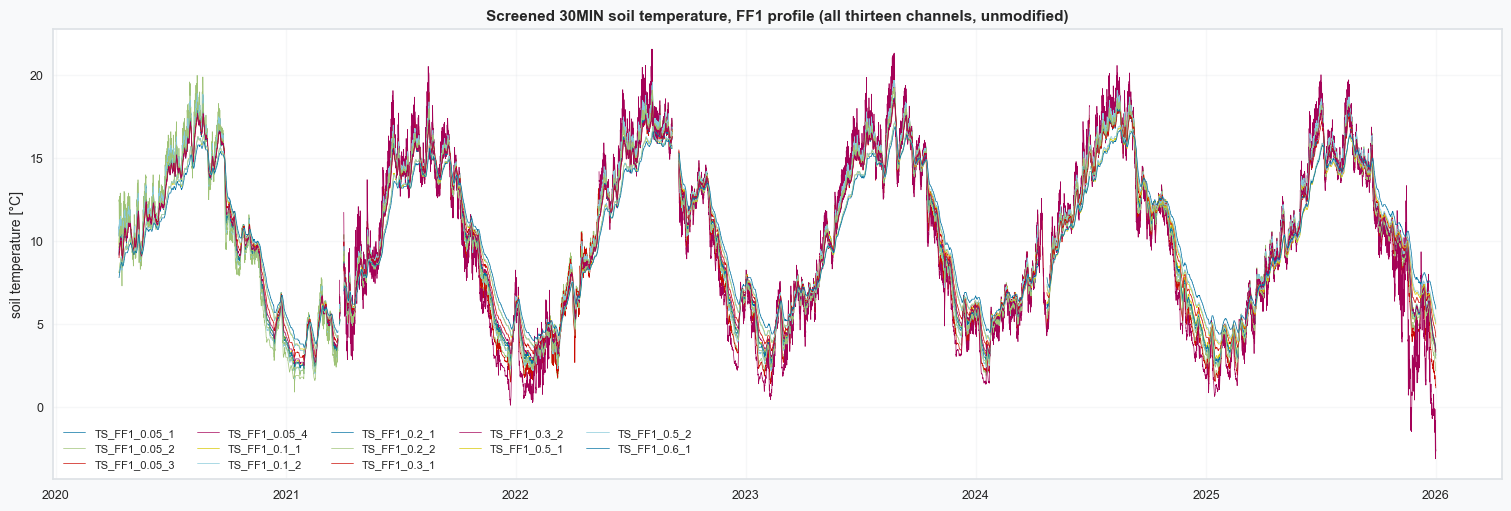

In [14]:
_peryear = pd.DataFrame({c: ts[c].groupby(ts.index.year).count() for c in CHANNELS})
_peryear.index.name = 'year'
display(_peryear)

fig, ax = plt.subplots(figsize=(15, 5), dpi=100, layout='constrained')
for c in CHANNELS:
    ax.plot(ts.index, ts[c], lw=.5, label=c)
ax.set_ylabel('soil temperature [°C]')
ax.set_title('Screened 30MIN soil temperature, FF1 profile (all thirteen channels, unmodified)')
ax.legend(ncol=5, fontsize=8)
plt.show()

***

## 💾 Save to file

Parquet only. No csv twin: this is an intermediate that one notebook reads, not a published
product, and thirteen float columns over six years make a csv nobody should be opening by hand.
`09` writes both because it *is* a product.

In [15]:
EXPORT_COLS = list(CHANNELS)
export_df = ts[EXPORT_COLS].copy()

filepath = dv.save_parquet(filename=OUTNAME, data=export_df, outpath=OUTPATH)
print(f"Saved to: {filepath}")

> Saved file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_DIIVE_2020-2025.parquet (0.120 seconds).

Saved to: F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS\TS_FF1_SCREENED_30MIN_DIIVE_2020-2025.parquet


### Verify the written file

Read it back and check that nothing changed on the way to disk — in particular that a gap did not
become a `0.0`, which for soil temperature is a physically possible value and would therefore be
invisible later.

In [16]:
_written = dv.load_parquet(filepath=str(Path(OUTPATH) / f"{OUTNAME}.parquet"))

print(f"columns ({len(_written.columns)}): {list(_written.columns)}")
print(f"index:   {_written.index[0]} -> {_written.index[-1]}  ({len(_written):,} records)\n")

assert list(_written.columns) == EXPORT_COLS, "unexpected columns in the written file"
assert len(_written) == len(export_df), "record count changed on write"
assert _written.index.equals(export_df.index), "index changed on write"
for _c in EXPORT_COLS:
    assert int(_written[_c].notna().sum()) == int(export_df[_c].notna().sum()), \
        f"{_c}: non-null count changed on write - gaps may have become zeros"
    assert abs(float(_written[_c].sum()) - float(export_df[_c].sum())) < 1e-6, \
        f"{_c}: values changed on write"
print("Written parquet verified.")

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\TS_FF1_SCREENED_30MIN_DIIVE_2020-2025.parquet (0.012 seconds).

columns (13): ['TS_FF1_0.05_1', 'TS_FF1_0.05_2', 'TS_FF1_0.05_3', 'TS_FF1_0.05_4', 'TS_FF1_0.1_1', 'TS_FF1_0.1_2', 'TS_FF1_0.2_1', 'TS_FF1_0.2_2', 'TS_FF1_0.3_1', 'TS_FF1_0.3_2', 'TS_FF1_0.5_1', 'TS_FF1_0.5_2', 'TS_FF1_0.6_1']
index:   2020-04-10 00:15:00 -> 2025-12-31 23:45:00  (100,416 records)

Written parquet verified.


### 📈 What the written file holds

The exported file, read back from disk and drawn as it stands — no correction, no gap-filling, no
homogenisation, exactly as the sections above promised. If a panel looks wrong, the file is wrong.

The three coverage shapes named earlier are the ones to find, all of them site history: eleven
SDI-12 channels from 2020-04-10, the two Campbell 109s at 0.05 m starting at the March 2021 logger
rebuild, and the long hole in `TS_FF1_0.3_2` between the April 2024 failure and the March 2025
replacement. The narrow white stripes crossing *every* row at once are the station outages — the
same distinction the per-year table makes, made by eye.

The daily-mean panel adds the profile's own consistency check, which no table shows: the seasonal
amplitude damps and its maximum lags from 0.05 m down to 0.6 m. Below 0.3 m stop trusting it —
those depths are quantised at 0.05 °C and their daily amplitude is two steps of the quantiser
(point 9 below), which is why this panel is seasonal rather than diurnal.

The value-range panel isolates one column: `TS_FF1_0.05_4` runs -3.12 to 21.58 °C while the other
twelve stay inside +0.90 to 20.60 °C. It is the shallowest and most exposed sensor and a different
make from its three neighbours at that depth, so a wider range is not by itself a fault — but it is
the same channel as the unresolved point 8 below, and the two are worth settling together.


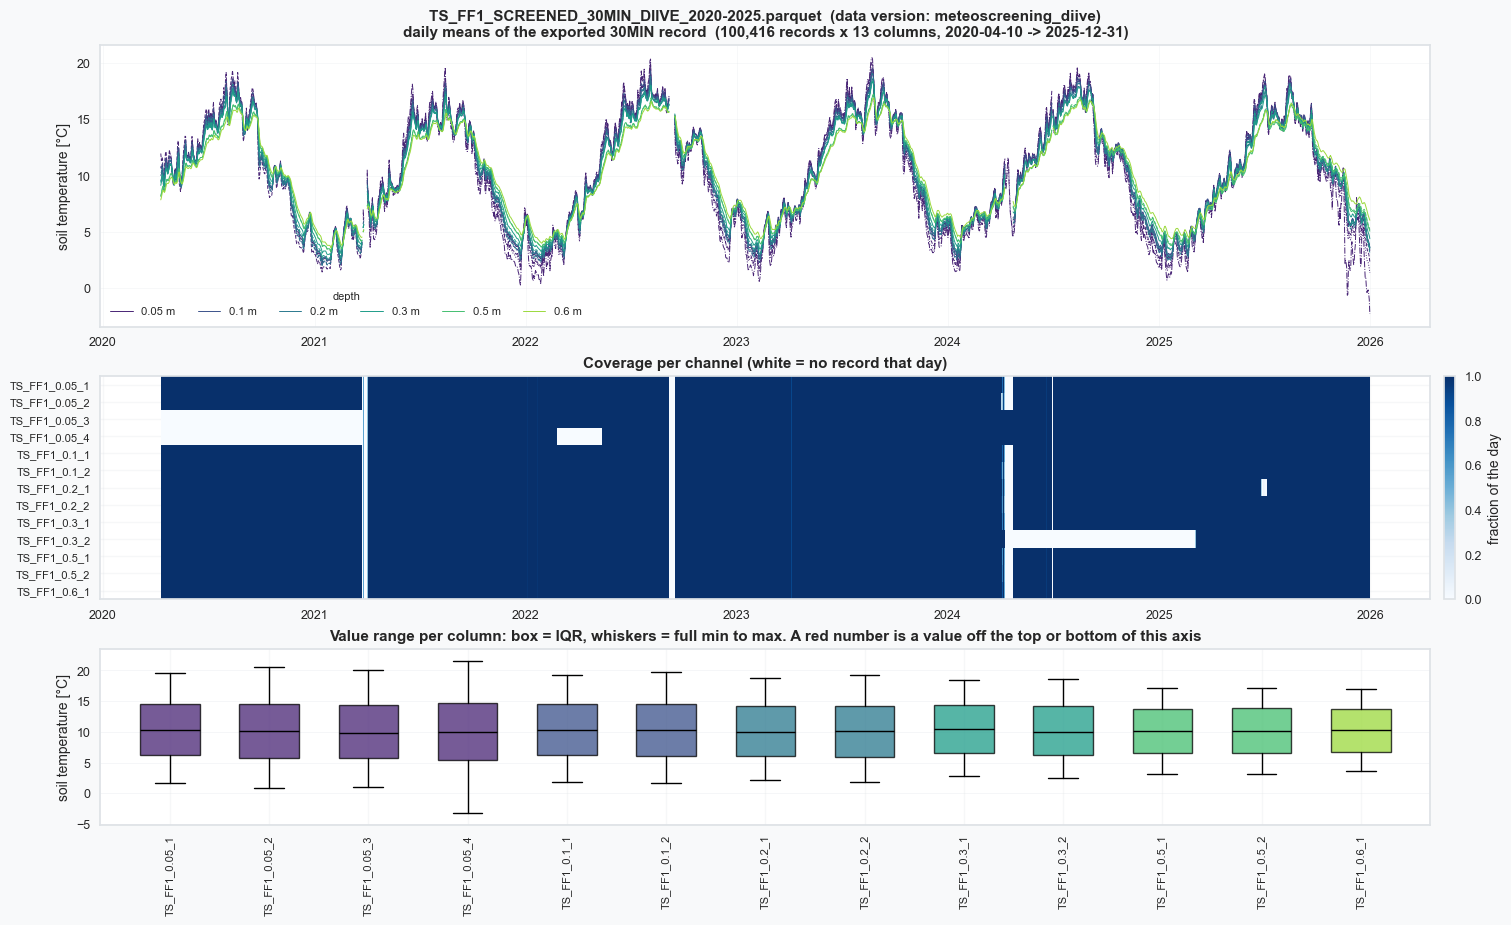

In [17]:
plot_written_file(_written,
                  title=f'{OUTNAME}.parquet  (data version: {DATA_VERSION})')


***

## ➡️ What `10` will have to decide

Written down here because this notebook is where the evidence is visible, and because none of it
can be answered from the exported files alone. `10_METEO_TS_FF1_2020-2025.ipynb` will need a
position on each.

**The naming problem comes first, because everything else depends on it.**

1. **What is `TS_PRF_FF1_*`, and how does it map onto today's depths?** Eighteen fields, depths
   this profile no longer has (0.15, 1.0, 1.5 m) and a third replicate at most depths. Nothing in
   this repo yet says what hardware it is. The fieldbook's device columns are the place to look —
   and note that for `SWC` the equivalent question was only answered by comparing a period where
   old and new names coexisted, not by reading names.
2. **Three names mean two different things.** `TS_FF1_0.05_1`, `_2` and `_3` exist in both data
   versions. Before April 2020 the `mst` values cannot be today's probes; after it the two
   versions overlap and are probably one measurement screened twice. A single column carrying all
   three phases would be a splice of two instruments with a tool change buried inside it.
3. **Is the overlap a calibration opportunity or a trap?** Unlike `SWC`, whose eras were disjoint
   and whose homogenisation therefore rested on climatology, there *is* an overlap here. If it is
   one measurement screened twice it says nothing about the old sensors; if the pre-2020 `mst`
   values come from the same physical probes as `TS_PRF_FF1_0.05_*`, then `TS_PRF_*` is the bridge
   to the old era and a real, measured offset becomes derivable. The overlap cell above is the
   first evidence either way.

**Then the product-shape questions, unchanged:**

4. **Which channels does the product export?** Thirteen channels at six depths is not a product
   shape — four sensors sit at 0.05 m alone, of three different makes. Either export all and let a
   flag explain them, or pick one per depth and say why.
5. **Every channel needs a `SOURCE` flag**, on the pattern of `09`, naming the sensor generation —
   now including the pre-2020 era, which is what these two files exist to make possible.
6. **`TS_FF1_0.3_2` is two probes under one name**, 326 days apart, the second ~40 cm downslope.
   The eras do not overlap, so no calibration can be derived from the data.
7. **The two Campbell 109s start 350 days late** and are the only channels that logged through the
   April 2024 SDI-12 bus failure, which makes them the only usable reference across it.
8. **`TS_FF1_0.05_4` has a suspect period screening deliberately left in**: elevated daily
   amplitude after the 23 Oct 2025 windstorm (3.38 K median in Nov 2025 against 0.37-0.71 K in
   earlier Novembers). Too ambiguous to remove at 1MIN; cheap to settle here against `0.05_3`.
9. **The depth ordering is the profile's own diagnostic** — amplitude damps and the daily maximum
   lags with depth — but **below 0.3 m it stops discriminating**, because a 0.10 K daily amplitude
   is two steps of the 0.05 °C storage quantiser. Use the seasonal wave at those depths.
10. **Gaps stay gaps unless a decision is made to fill them.** Nothing here is filled, and the
    five shared outages are station events, not sensor events — including 2024-06-30, which has no
    fieldbook entry at all.

***

## End of notebook.

In [18]:
NOTEBOOK_END = datetime.now()
_h, _rem = divmod(int((NOTEBOOK_END - NOTEBOOK_START).total_seconds()), 3600)
_m, _s = divmod(_rem, 60)

print(f"Started:  {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Finished: {NOTEBOOK_END.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Runtime:  {_h:02d}:{_m:02d}:{_s:02d} (hh:mm:ss)")

Started:  2026-07-22 23:52:15
Finished: 2026-07-22 23:53:44
Runtime:  00:01:29 (hh:mm:ss)
